In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score

In [10]:
df = pd.read_csv("D:/new project/Smog_Towers_Project/ML/AQI_Dataset.csv",encoding='latin-1')
df = df.rename(columns={df.columns[0]: 'Ammonia'})
'''
Using basic methods to inspect the DataFrame:

- head(): Displays the first 5 rows of the dataset to get an overview of the data.
- shape: Returns the dimensions (number of rows and columns) of the DataFrame.
- describe(): Provides basic statistical details for numeric columns.
- info(): Displays concise summary of the DataFrame including data types and non-null counts.
'''
print(df.head())
print(df.shape)
print(df.describe())
print(df.info())
print(df.columns)

   Ammonia  Benzene  Alcohol     CO  Methane   CNG   LPG  Butane  Hydrogen  \
0    41.56     3.86     8.10   6.45     7.71  9.76  4.74    6.56      7.99   
1    39.29     2.32     9.46   7.90     1.61  6.70  0.28    2.63      9.89   
2    31.26     0.17     4.95   1.40     7.05  2.91  0.45    2.03      4.20   
3     8.41     3.26     8.90  13.84     5.84  5.62  5.17    7.33      8.35   
4     5.28     4.39     8.56  13.05     4.53  3.86  2.47    9.42      8.37   

    Smoke  Propane     AQI  
0   35.70     2.99  143.27  
1  175.77     6.27  197.50  
2   79.12     6.16  105.75  
3   15.59     8.59   97.39  
4  108.53     6.85  136.43  
(5000, 12)
           Ammonia      Benzene      Alcohol           CO      Methane  \
count  5000.000000  5000.000000  5000.000000  5000.000000  5000.000000   
mean     25.114296     2.517466     4.972800    10.080650     5.029088   
std      14.398793     1.443419     2.853678     5.766387     2.878648   
min       0.010000     0.000000     0.000000     0

In [11]:
# Keep only the specified columns in the DataFrame
columns_to_keep = ['Ammonia', 'Benzene', 'CNG', 'CO', 'Hydrogen', 'LPG', 'Smoke', 'AQI']
df = df[columns_to_keep]
print("Columns after filtering:", df.columns.tolist())

Columns after filtering: ['Ammonia', 'Benzene', 'CNG', 'CO', 'Hydrogen', 'LPG', 'Smoke', 'AQI']


In [12]:
# Checking for missing values in each column of the DataFrame
print(df.isnull().sum())

Ammonia     0
Benzene     0
CNG         0
CO          0
Hydrogen    0
LPG         0
Smoke       0
AQI         0
dtype: int64


In [13]:
# Calculate the correlation matrix
correlation_matrix = df.corr()

# Display the correlation matrix
print(correlation_matrix)

           Ammonia   Benzene       CNG        CO  Hydrogen       LPG  \
Ammonia   1.000000 -0.004518 -0.016182 -0.026699 -0.030961  0.013025   
Benzene  -0.004518  1.000000  0.005596  0.006567  0.005628  0.022875   
CNG      -0.016182  0.005596  1.000000  0.010267 -0.002349 -0.010464   
CO       -0.026699  0.006567  0.010267  1.000000 -0.015562  0.002436   
Hydrogen -0.030961  0.005628 -0.002349 -0.015562  1.000000  0.024405   
LPG       0.013025  0.022875 -0.010464  0.002436  0.024405  1.000000   
Smoke     0.001885 -0.002840  0.004490 -0.013469 -0.013132  0.002803   
AQI       0.273370  0.075045  0.063209  0.152388  0.100206  0.117889   

             Smoke       AQI  
Ammonia   0.001885  0.273370  
Benzene  -0.002840  0.075045  
CNG       0.004490  0.063209  
CO       -0.013469  0.152388  
Hydrogen -0.013132  0.100206  
LPG       0.002803  0.117889  
Smoke     1.000000  0.882895  
AQI       0.882895  1.000000  


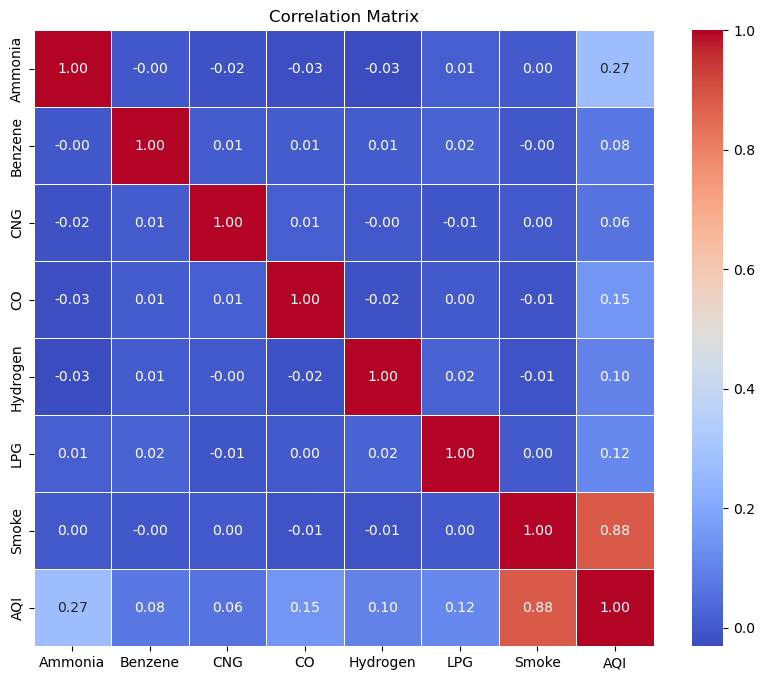

In [14]:
# Create a heatmap of the correlation matrix
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title("Correlation Matrix")
plt.show()

In [15]:
#Getting the Value Counts
df['AQI'].value_counts()

AQI
159.28    4
121.06    4
168.37    4
127.21    4
106.86    4
         ..
132.35    1
193.43    1
178.68    1
111.45    1
136.83    1
Name: count, Length: 4222, dtype: int64

In [16]:
df['Ammonia'].value_counts()

Ammonia
4.85     6
15.90    6
17.26    5
41.64    5
4.86     5
        ..
8.56     1
31.30    1
12.57    1
36.16    1
39.99    1
Name: count, Length: 3169, dtype: int64

In [17]:
df['Benzene'].value_counts()

Benzene
4.97    20
2.39    19
3.16    19
1.94    18
3.81    18
        ..
3.77     3
3.78     3
0.24     3
2.90     2
0.66     2
Name: count, Length: 501, dtype: int64

In [19]:
df['CO'].value_counts()

CO
6.18     9
18.17    9
3.39     9
4.40     9
16.78    8
        ..
1.73     1
1.03     1
3.41     1
6.84     1
8.67     1
Name: count, Length: 1826, dtype: int64

In [21]:
df['CNG'].value_counts()

CNG
3.64    17
1.54    13
6.11    12
2.53    12
0.04    12
        ..
2.69     1
3.71     1
6.88     1
8.33     1
1.32     1
Name: count, Length: 998, dtype: int64

In [22]:
df['LPG'].value_counts()

LPG
1.93    13
0.09    13
3.86    12
3.13    12
7.37    12
        ..
0.15     1
5.46     1
5.76     1
7.70     1
7.39     1
Name: count, Length: 997, dtype: int64

In [73]:
df['Hydrogen'].value_counts()

Hydrogen
9.14    13
0.51    12
9.66    12
6.54    12
7.64    11
        ..
0.37     1
2.98     1
3.10     1
8.61     1
4.56     1
Name: count, Length: 994, dtype: int64

In [25]:
df['Smoke'].value_counts()

Smoke
117.92    4
26.98     4
14.55     4
39.81     4
128.31    3
         ..
199.68    1
0.39      1
93.96     1
172.29    1
98.60     1
Name: count, Length: 4417, dtype: int64

In [74]:
import pandas as pd
import numpy as np

def check_problematic_features(X, y):
    """
    Identifies problematic features including:
    - Leaky features (perfectly correlated with target)
    - Near-constant features
    - Duplicate features
    """
    
    # 1. Check for leaky features (correlation with target)
    print("=== Correlation with Target ===")
    correlations = X.corrwith(y)
    suspicious_features = correlations[abs(correlations) > 0.95].index.tolist()  # Threshold adjustable
    print(correlations.sort_values(ascending=False))
    
    if suspicious_features:
        print(f"\n🚨 Warning: Highly correlated features (possible leakage): {suspicious_features}")
    
    # 2. Check for constant/near-constant features
    print("\n=== Constant/Near-Constant Features ===")
    nunique_counts = X.nunique().sort_values()
    constant_features = nunique_counts[nunique_counts <= 1].index.tolist()  # Exactly 1 unique value
    near_constant_features = nunique_counts[nunique_counts <= 5].index.tolist()  # Adjust threshold as needed
    
    if constant_features:
        print(f"Constant features (0 variance): {constant_features}")
    if near_constant_features:
        print(f"Near-constant features (≤5 unique values): {near_constant_features}")
    
    # 3. Check for duplicated features
    print("\n=== Duplicate Features ===")
    duplicated_features = set()
    X_T = X.T.round(3)  # Rounding to avoid floating-point errors
    duplicates = X_T.duplicated()
    
    if duplicates.any():
        duplicated_features = set(X_T.index[duplicates])
        print(f"Duplicate features: {duplicated_features}")
    else:
        print("No duplicate features found")
    
    # Return all problematic features
    problematic_features = list(set(suspicious_features + constant_features + near_constant_features + list(duplicated_features)))
    return problematic_features

# Usage example:
# X = df.drop('AQI', axis=1)  # Ensure target is removed first!
# y = df['AQI']
# problematic_features = check_problematic_features(X, y)
# X_clean = X.drop(problematic_features, axis=1)

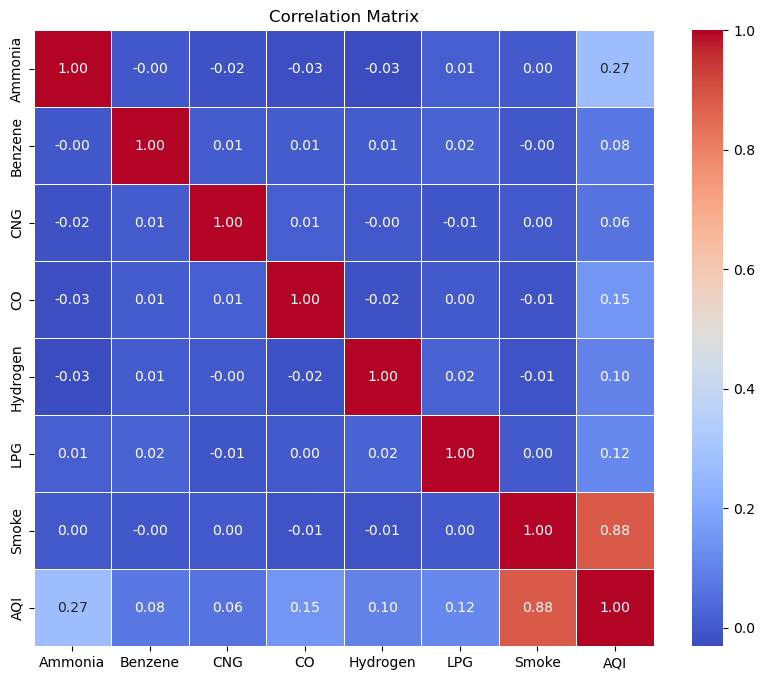

In [97]:
# Create a heatmap of the correlation matrix (After data pre-processing)
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title("Correlation Matrix")
plt.show()

In [117]:
from sklearn.preprocessing import StandardScaler

# 1. Focus on strong predictors
important_features = ['Smoke', 'CO']  # CQ has 0.15 correlation

# 2. Investigate the unlabeled column
print(df.columns[0])  # Identify the unnamed feature

# 3. Consider removing weak predictors
weak_features = ['Benzene', 'CNG', 'Hydrogen', 'LPG', 'AQI']

# 4. Verify Ammonia data
if 'Ammonia' in df.columns:
    print("Ammonia-AQI correlation:", df['Ammonia'].corr(df['AQI']))

# Features: pollutant AQI values
X = df[['Ammonia', 'Benzene', 'CNG', 'CO', 'Hydrogen', 'LPG', 'Smoke', 'AQI']]
X = X.drop(weak_features, axis=1)

scaler = StandardScaler()
X[['Smoke', 'CO']] = scaler.fit_transform(X[['Smoke', 'CO']])

# Target: overall AQI
y = df['AQI']

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Run diagnostics
problematic_features = check_problematic_features(X, y)

# Clean data
if problematic_features:
    print(f"\nRecommended action: Drop these features - {problematic_features}")
    X_clean = X.drop(problematic_features, axis=1)
else:
    print("\nNo problematic features found")
    X_clean = X.copy()

Ammonia
Ammonia-AQI correlation: 0.2733702406444525
=== Correlation with Target ===
Smoke      0.882895
Ammonia    0.273370
CO         0.152388
dtype: float64

=== Constant/Near-Constant Features ===

=== Duplicate Features ===
No duplicate features found

No problematic features found


In [118]:
# Check if any feature is perfectly correlated with the target
correlations = X.corrwith(y)
print("Correlation with Target:\n", correlations.sort_values(ascending=False))

# Check for duplicate or constant features
print("\nConstant/Duplicate Features:")
print(X.nunique().sort_values())

Correlation with Target:
 Smoke      0.882895
Ammonia    0.273370
CO         0.152388
dtype: float64

Constant/Duplicate Features:
CO         1826
Ammonia    3169
Smoke      4417
dtype: int64


In [119]:
# Confirm test data is truly unseen
assert not np.array_equal(X_train, X_test), "Train and test sets are identical!"

In [120]:
from sklearn.dummy import DummyRegressor

dummy = DummyRegressor(strategy="mean")
dummy.fit(X_train, y_train)
print("Dummy Model R²:", r2_score(y_test, dummy.predict(X_test)))

Dummy Model R²: -0.0018004329398557672


In [121]:
# ========== Model 1: Linear Regression ==========
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
lr_preds = lr_model.predict(X_test)

In [122]:
# ========== Model 2: Random Forest Regressor ==========
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_test)

In [123]:
# ========== Model 3: Decision Tree Regressor ==========
from sklearn.tree import DecisionTreeRegressor

dt_model = DecisionTreeRegressor(random_state=42)
dt_model.fit(X_train, y_train)
dt_preds = dt_model.predict(X_test)

In [124]:
# ========== Model 4: K-Nearest Neighbors Regressor ==========
from sklearn.neighbors import KNeighborsRegressor

knn_model = KNeighborsRegressor(n_neighbors=5)  # You can tune n_neighbors
knn_model.fit(X_train, y_train)
knn_preds = knn_model.predict(X_test)

In [125]:
# ========== Predictions ==========
lr_preds = lr_model.predict(X_test)
rf_preds = rf_model.predict(X_test)
dt_preds = dt_model.predict(X_test)
knn_preds = knn_model.predict(X_test)

def evaluate(y_true, y_pred, model_name):
    print(f"\n--- {model_name} Evaluation ---")
    print("RMSE:", np.sqrt(mean_squared_error(y_true, y_pred)))
    print("R^2 Score:", r2_score(y_true, y_pred))

# ========== Evaluate All Models ==========
evaluate(y_test, lr_preds, "Linear Regression")
evaluate(y_test, rf_preds, "Random Forest Regressor")
evaluate(y_test, dt_preds, "Decision Tree Regressor")
evaluate(y_test, knn_preds, "K-Nearest Neighbors Regressor")


--- Linear Regression Evaluation ---
RMSE: 14.026444395427337
R^2 Score: 0.87794918047323

--- Random Forest Regressor Evaluation ---
RMSE: 15.16008500736688
R^2 Score: 0.857423225936895

--- Decision Tree Regressor Evaluation ---
RMSE: 20.368577751036028
R^2 Score: 0.7426246670546319

--- K-Nearest Neighbors Regressor Evaluation ---
RMSE: 16.259225387699132
R^2 Score: 0.8359994842565065


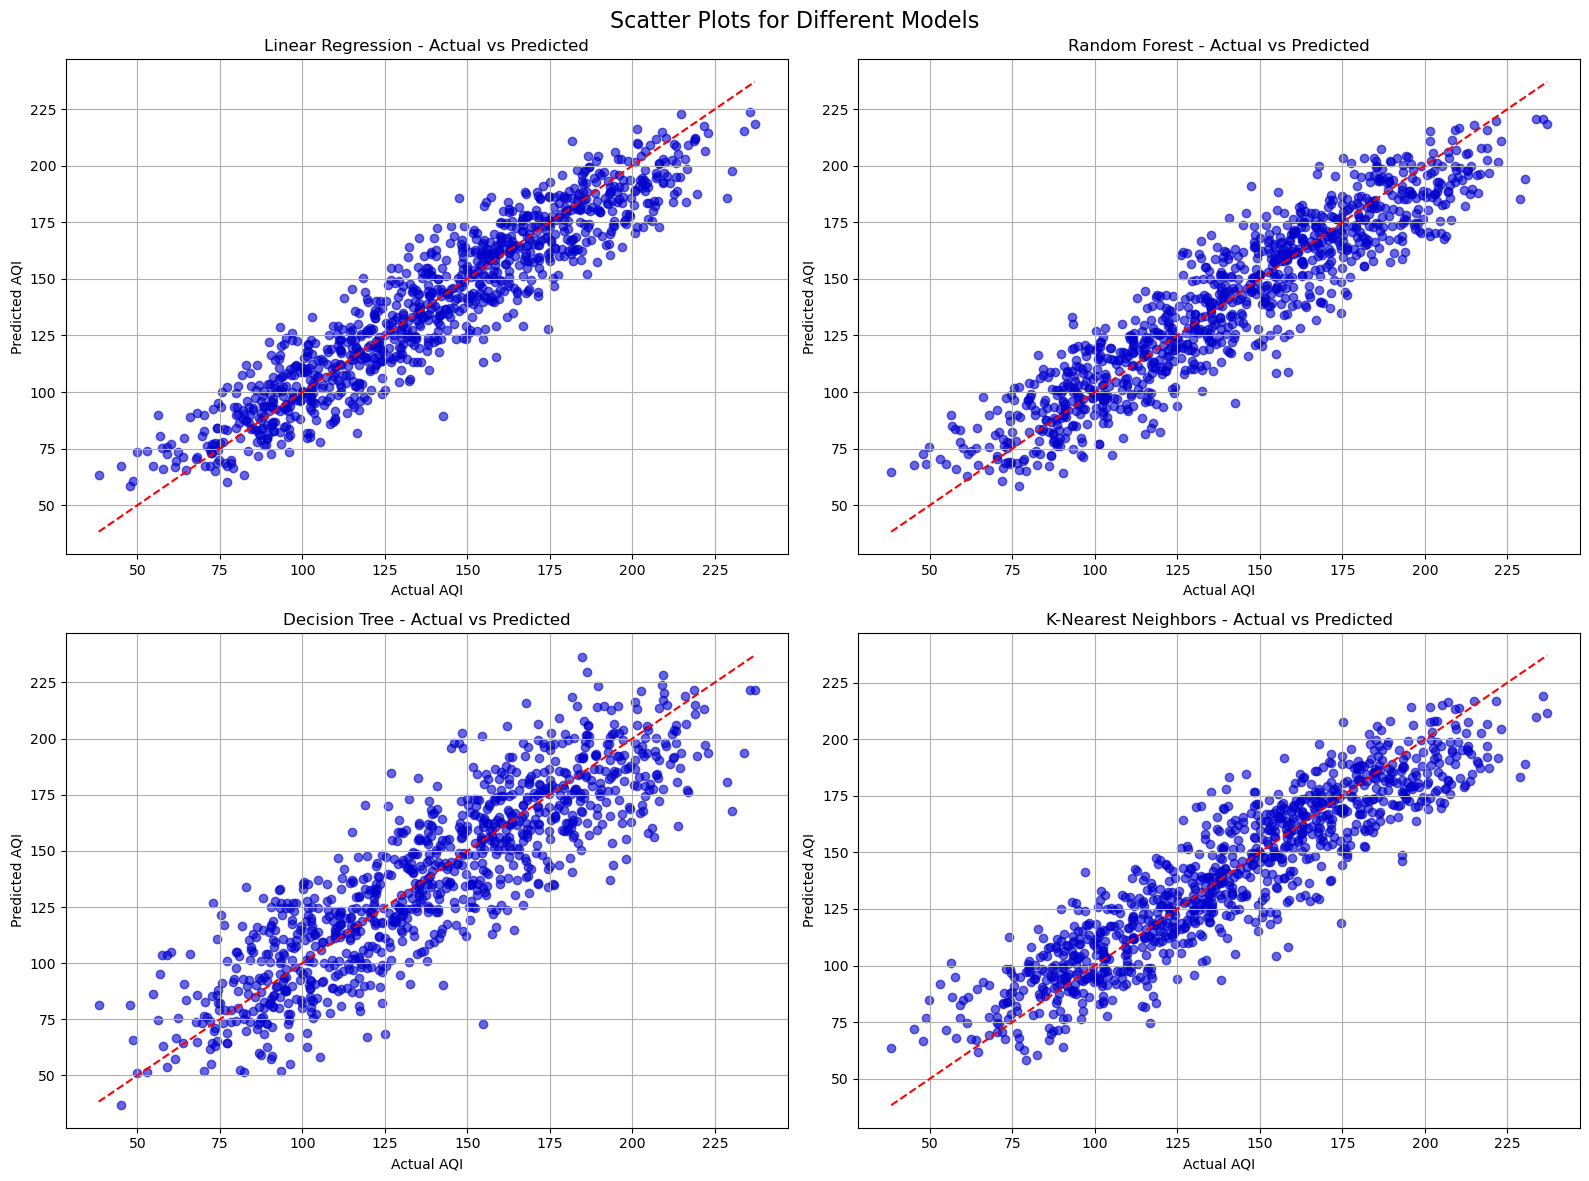

In [134]:
# ========== Visualize Predictions ==========
# Set up figure
plt.figure(figsize=(16, 12))
plt.suptitle("Scatter Plots for Different Models", fontsize=16)

# List of models and their predictions
models = {
    "Linear Regression": lr_preds,
    "Random Forest": rf_preds,
    "Decision Tree": dt_preds,
    "K-Nearest Neighbors": knn_preds
}

# Plot actual vs predicted for each model
for i, (name, preds) in enumerate(models.items(), 1):
    plt.subplot(2, 2, i)  # 2x2 grid
    plt.scatter(y_test, preds, alpha=0.6, color='mediumblue')
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')  # Perfect prediction line
    plt.xlabel("Actual AQI")
    plt.ylabel("Predicted AQI")
    plt.title(f"{name} - Actual vs Predicted")
    plt.grid(True)

plt.tight_layout()
plt.show()

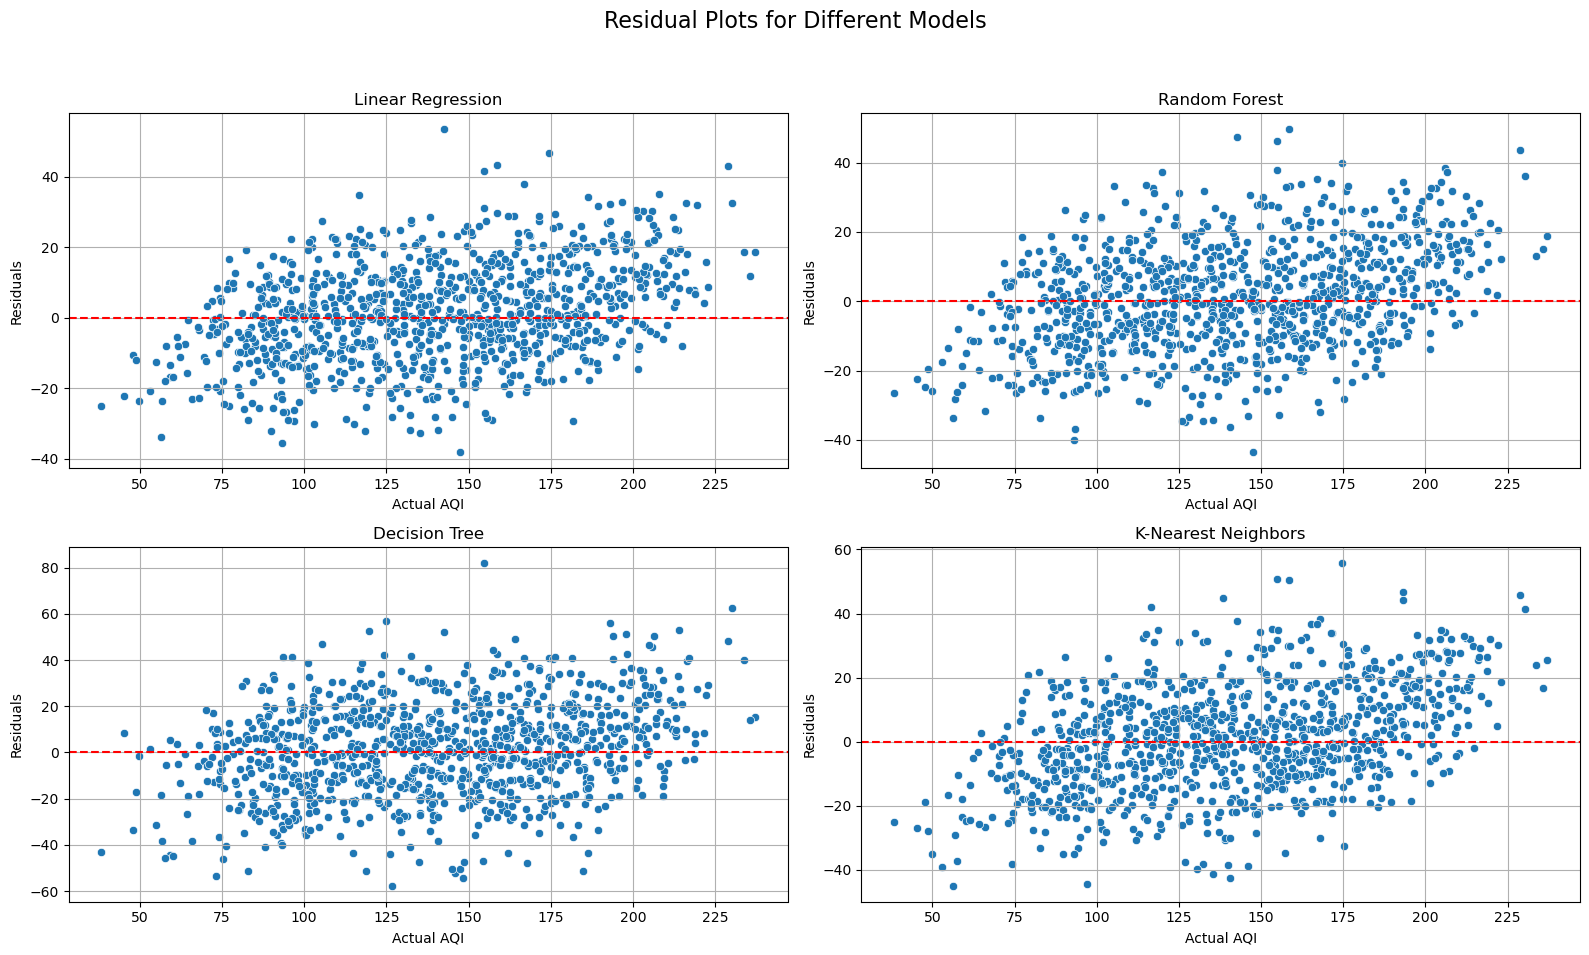

In [127]:
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming y_test, lr_preds, rf_preds, dt_preds, knn_preds are already defined

# Create residuals
residuals_lr = y_test - lr_preds
residuals_rf = y_test - rf_preds
residuals_dt = y_test - dt_preds
residuals_knn = y_test - knn_preds

# Set up subplots
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle("Residual Plots for Different Models", fontsize=16)

# Plot for Linear Regression
sns.scatterplot(x=y_test, y=residuals_lr, ax=axes[0, 0])
axes[0, 0].axhline(0, color='red', linestyle='--')
axes[0, 0].set_title("Linear Regression")
axes[0, 0].set_xlabel("Actual AQI")
axes[0, 0].set_ylabel("Residuals")
axes[0, 0].grid(True)

# Plot for Random Forest
sns.scatterplot(x=y_test, y=residuals_rf, ax=axes[0, 1])
axes[0, 1].axhline(0, color='red', linestyle='--')
axes[0, 1].set_title("Random Forest")
axes[0, 1].set_xlabel("Actual AQI")
axes[0, 1].set_ylabel("Residuals")
axes[0, 1].grid(True)

# Plot for Decision Tree
sns.scatterplot(x=y_test, y=residuals_dt, ax=axes[1, 0])
axes[1, 0].axhline(0, color='red', linestyle='--')
axes[1, 0].set_title("Decision Tree")
axes[1, 0].set_xlabel("Actual AQI")
axes[1, 0].set_ylabel("Residuals")
axes[1, 0].grid(True)

# Plot for K-Nearest Neighbors
sns.scatterplot(x=y_test, y=residuals_knn, ax=axes[1, 1])
axes[1, 1].axhline(0, color='red', linestyle='--')
axes[1, 1].set_title("K-Nearest Neighbors")
axes[1, 1].set_xlabel("Actual AQI")
axes[1, 1].set_ylabel("Residuals")
axes[1, 1].grid(True)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])  # Adjust layout to make space for the main title
plt.show()

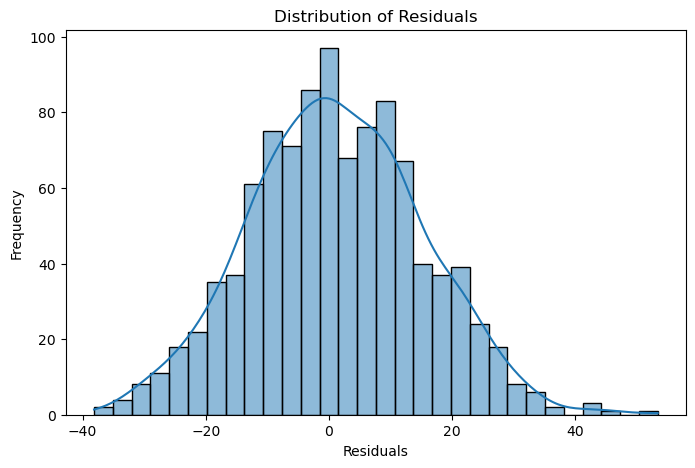

In [128]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

# Assuming your data is in X (features) and y (target, e.g., AQI)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Define and train the model
model = LinearRegression()
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

# Calculate residuals
residuals = y_test - y_pred

# Plot residuals
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
sns.histplot(residuals, bins=30, kde=True)
plt.title("Distribution of Residuals")
plt.xlabel("Residuals")
plt.ylabel("Frequency")
plt.show()


C:\Users\USER\AppData\Local\Temp\ipykernel_3196\2972503322.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=model_names, y=r2_scores, palette="Blues_d")


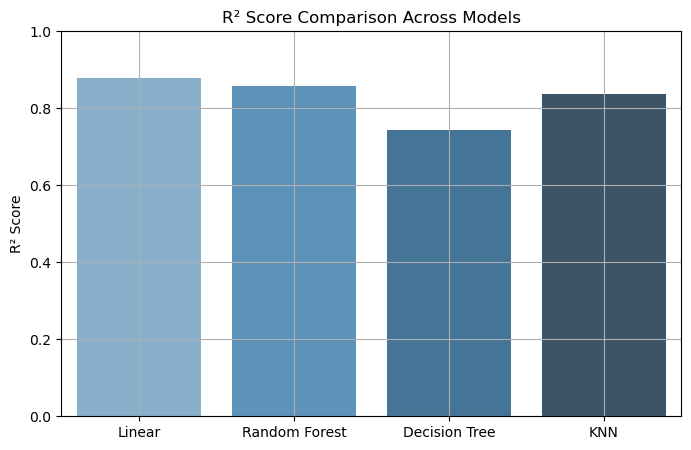

In [129]:
r2_scores = [
    r2_score(y_test, lr_preds),
    r2_score(y_test, rf_preds),
    r2_score(y_test, dt_preds),
    r2_score(y_test, knn_preds)
]
model_names = ["Linear", "Random Forest", "Decision Tree", "KNN"]

plt.figure(figsize=(8, 5))
sns.barplot(x=model_names, y=r2_scores, palette="Blues_d")
plt.title("R² Score Comparison Across Models")
plt.ylabel("R² Score")
plt.ylim(0, 1)
plt.grid(True)
plt.show()

R² Scores:
Linear Regression: 0.8779
Random Forest: 0.8574
Decision Tree: 0.7426
KNN: 0.8360


C:\Users\USER\AppData\Local\Temp\ipykernel_3196\3514442086.py:55: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(model_scores.keys()), y=list(model_scores.values()), palette="Blues_d")


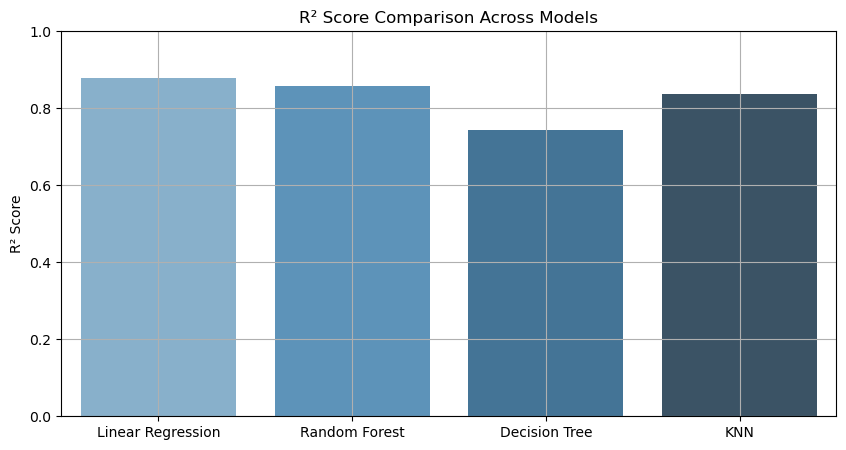


🎯 Final Best Model: Linear Regression (R²: 0.8779)


In [139]:
# Import libraries
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import r2_score
import pickle
import matplotlib.pyplot as plt
import seaborn as sns

# Load your data (replace with your actual data loading)
# df = pd.read_csv('your_data.csv')
# X = df.drop('AQI', axis=1)  # Features
# y = df['AQI']               # Target

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize models (with basic hyperparameters)
lr = LinearRegression()
rf = RandomForestRegressor(random_state=42)
dt = DecisionTreeRegressor(random_state=42)
knn = KNeighborsRegressor()

# Train models
lr.fit(X_train, y_train)
rf.fit(X_train, y_train)
dt.fit(X_train, y_train)
knn.fit(X_train, y_train)

# Get predictions
lr_preds = lr.predict(X_test)
rf_preds = rf.predict(X_test)
dt_preds = dt.predict(X_test)
knn_preds = knn.predict(X_test)

# Calculate R² scores
model_scores = {
    "Linear Regression": r2_score(y_test, lr_preds),
    "Random Forest": r2_score(y_test, rf_preds),
    "Decision Tree": r2_score(y_test, dt_preds),
    "KNN": r2_score(y_test, knn_preds)
}

# Print scores for verification
print("R² Scores:")
for name, score in model_scores.items():
    print(f"{name}: {score:.4f}")

# Visual comparison
plt.figure(figsize=(10, 5))
sns.barplot(x=list(model_scores.keys()), y=list(model_scores.values()), palette="Blues_d")
plt.title("R² Score Comparison Across Models")
plt.ylabel("R² Score")
plt.ylim(0, 1)
plt.grid(True)
plt.show()

# --- Hyperparameter Tuning for Random Forest (if it's the best) ---
if max(model_scores.values()) == model_scores["Random Forest"]:
    print("\n🚀 Tuning Random Forest...")
    
    # Define parameter grid
    param_grid = {
        'n_estimators': [50, 100, 200],
        'max_depth': [None, 10, 20, 30],
        'min_samples_split': [2, 5, 10]
    }
    
    # Grid search with cross-validation
    rf_tuned = RandomForestRegressor(random_state=42)
    grid_search = GridSearchCV(rf_tuned, param_grid, cv=5, scoring='r2', n_jobs=-1)
    grid_search.fit(X_train, y_train)
    
    # Get best model
    best_rf = grid_search.best_estimator_
    rf_tuned_preds = best_rf.predict(X_test)
    tuned_r2 = r2_score(y_test, rf_tuned_preds)
    
    print(f"✅ Best Parameters: {grid_search.best_params_}")
    print(f"✅ Tuned R² Score: {tuned_r2:.4f} (Original: {model_scores['Random Forest']:.4f})")
    
    # Update best model
    best_model = best_rf
    best_model_name = "Random Forest (Tuned)"
    
else:
    # Fallback to the best non-tuned model
    best_model_name = max(model_scores, key=model_scores.get)
    if best_model_name == "Linear Regression":
        best_model = lr
    elif best_model_name == "Random Forest":
        best_model = rf
    elif best_model_name == "Decision Tree":
        best_model = dt
    else:
        best_model = knn

# Save the best model
with open('predictor.pickle', 'wb') as file:
    pickle.dump(best_model, file)

print(f"\n🎯 Final Best Model: {best_model_name} (R²: {max(model_scores.values()):.4f})")

In [138]:
from sklearn.model_selection import cross_val_score

models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(random_state=42),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "KNN": KNeighborsRegressor()
}

cv_results = {}
for name, model in models.items():
    scores = cross_val_score(model, X, y, cv=5, scoring='r2')
    cv_results[name] = scores.mean()
    print(f"{name} CV R²: {scores.mean():.4f} ± {scores.std():.4f}")

best_model_name = max(cv_results, key=cv_results.get)
print(f"Best model by CV: {best_model_name}")

Linear Regression CV R²: 0.8825 ± 0.0026
Random Forest CV R²: 0.8621 ± 0.0048
Decision Tree CV R²: 0.7498 ± 0.0125
KNN CV R²: 0.8422 ± 0.0050
Best model by CV: Linear Regression


In [140]:
from sklearn.ensemble import GradientBoostingRegressor

# Add Gradient Boosting to the models
models["Gradient Boosting"] = GradientBoostingRegressor(random_state=42)

# Re-run cross-validation including Gradient Boosting
cv_results = {}
for name, model in models.items():
    scores = cross_val_score(model, X, y, cv=5, scoring='r2')
    cv_results[name] = scores.mean()
    print(f"{name} CV R²: {scores.mean():.4f} ± {scores.std():.4f}")

best_model_name = max(cv_results, key=cv_results.get)
print(f"Best model by CV (including Gradient Boosting): {best_model_name}")

Linear Regression CV R²: 0.8825 ± 0.0026
Random Forest CV R²: 0.8621 ± 0.0048
Decision Tree CV R²: 0.7498 ± 0.0125
KNN CV R²: 0.8422 ± 0.0050
Gradient Boosting CV R²: 0.8777 ± 0.0030
Best model by CV (including Gradient Boosting): Linear Regression


## AQI Forecasting Using ARIMA and LSTM on Predicted AQI (from Gas Data)

We will use the trained Linear Regression model to generate AQI predictions from new gas sensor data, then apply ARIMA and LSTM to forecast future AQI levels.

In [144]:
import pandas as pd
import numpy as np
import pickle

# Load gas data (ensure columns match: Ammonia, Benzene, CNG, CO, Hydrogen, LPG, Smoke)
gas_data = pd.read_csv("D:/new project/Smog_Towers_Project/ML/AQI_Dataset.csv")
df = df.rename(columns={df.columns[0]: 'Ammonia'})

# Load the trained Linear Regression model
with open('predictor.pickle', 'rb') as f:
    lr_model = pickle.load(f)

# Predict AQI using the gas data
aqi_pred = lr_model.predict(gas_data[['Ammonia', 'CO', 'Smoke']])
aqi_pred_series = pd.Series(aqi_pred, name='Predicted_AQI')

# For time series forecasting, treat this as a univariate series
print(aqi_pred_series.head())

0    1470.151609
1    6480.405149
2    2978.374081
3     776.749270
4    4087.983638
Name: Predicted_AQI, dtype: float64


### ARIMA Forecasting on Predicted AQI

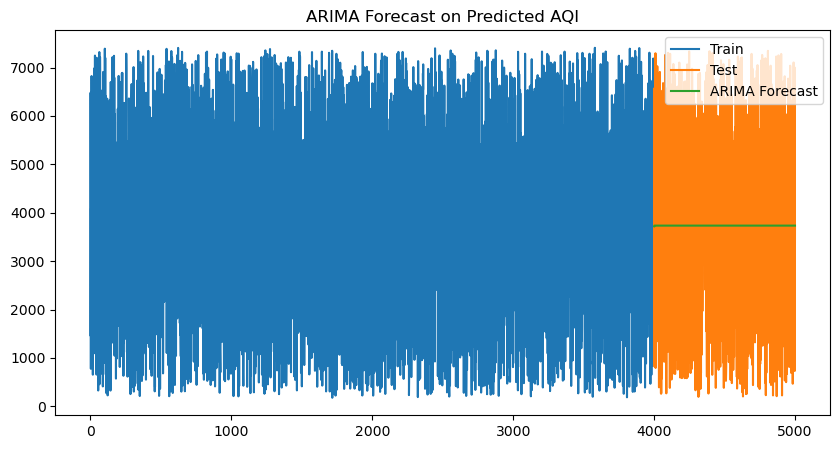

ARIMA RMSE: 2035.999868391959


In [145]:
from statsmodels.tsa.arima.model import ARIMA
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error

# Use 80% for training, 20% for testing
train_size = int(len(aqi_pred_series) * 0.8)
train, test = aqi_pred_series[:train_size], aqi_pred_series[train_size:]

# Fit ARIMA model (order can be tuned)
arima_model = ARIMA(train, order=(2,1,2))
arima_fit = arima_model.fit()

# Forecast next N steps
arima_forecast = arima_fit.forecast(steps=len(test))

# Plot
plt.figure(figsize=(10,5))
plt.plot(train.index, train, label='Train')
plt.plot(test.index, test, label='Test')
plt.plot(test.index, arima_forecast, label='ARIMA Forecast')
plt.legend()
plt.title('ARIMA Forecast on Predicted AQI')
plt.show()

# Print RMSE
print('ARIMA RMSE:', np.sqrt(mean_squared_error(test, arima_forecast)))

### LSTM Forecasting on Predicted AQI

c:\Users\USER\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - loss: 0.1575
Epoch 2/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0813
Epoch 3/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0813
Epoch 4/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0795
Epoch 5/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0816
Epoch 6/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0794
Epoch 7/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0819
Epoch 8/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.0799
Epoch 9/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0795
Epoch 10/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0812
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step


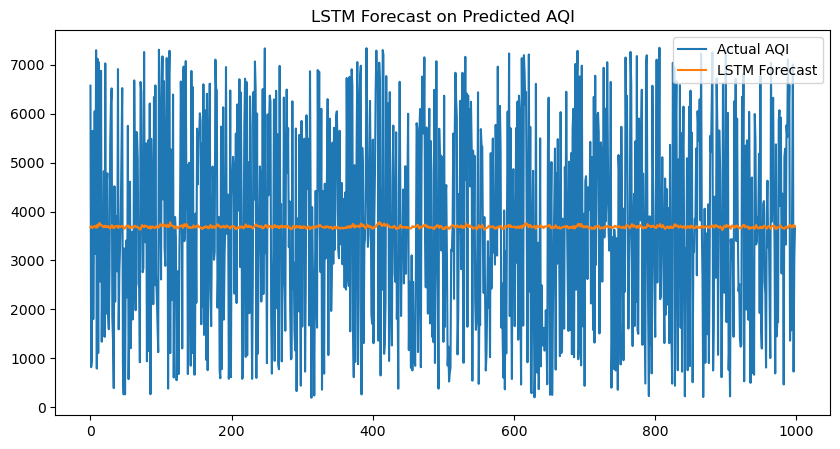

LSTM RMSE: 2037.971328857802


In [146]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from sklearn.preprocessing import MinMaxScaler

# Scale the data
scaler = MinMaxScaler()
scaled_aqi = scaler.fit_transform(aqi_pred_series.values.reshape(-1,1))

# Create sequences for LSTM
def create_sequences(data, seq_length=5):
    X, y = [], []
    for i in range(len(data)-seq_length):
        X.append(data[i:i+seq_length])
        y.append(data[i+seq_length])
    return np.array(X), np.array(y)

seq_length = 5
X_lstm, y_lstm = create_sequences(scaled_aqi, seq_length)

# Train/test split
split = int(0.8 * len(X_lstm))
X_train, X_test = X_lstm[:split], X_lstm[split:]
y_train, y_test = y_lstm[:split], y_lstm[split:]

# Build and train LSTM model
lstm_model = Sequential([
    LSTM(50, activation='relu', input_shape=(seq_length, 1)),
    Dense(1)
])
lstm_model.compile(optimizer='adam', loss='mse')
lstm_model.fit(X_train, y_train, epochs=10, batch_size=16, verbose=1)

# Predict and inverse scale
lstm_preds = lstm_model.predict(X_test)
lstm_preds_inv = scaler.inverse_transform(lstm_preds)
y_test_inv = scaler.inverse_transform(y_test)

# Plot
plt.figure(figsize=(10,5))
plt.plot(y_test_inv, label='Actual AQI')
plt.plot(lstm_preds_inv, label='LSTM Forecast')
plt.legend()
plt.title('LSTM Forecast on Predicted AQI')
plt.show()

# Print RMSE
print('LSTM RMSE:', np.sqrt(mean_squared_error(y_test_inv, lstm_preds_inv)))

## Selecting the Best Model for AQI Forecasting

We have used the trained Linear Regression model to generate AQI predictions from gas sensor data. Now, we compare ARIMA and LSTM for time series forecasting of these predicted AQI values. The best model is chosen based on the lowest RMSE (Root Mean Squared Error) on the test set.

In [147]:
# Compare ARIMA and LSTM RMSE to select the best forecasting model

# ARIMA RMSE (from previous ARIMA cell)
arima_rmse = np.sqrt(mean_squared_error(test, arima_forecast))

# LSTM RMSE (from previous LSTM cell)
lstm_rmse = np.sqrt(mean_squared_error(y_test_inv, lstm_preds_inv))

print(f"ARIMA RMSE: {arima_rmse:.4f}")
print(f"LSTM RMSE: {lstm_rmse:.4f}")

if arima_rmse < lstm_rmse:
    best_forecast_model = "ARIMA"
    print("Best forecasting model: ARIMA")
else:
    best_forecast_model = "LSTM"
    print("Best forecasting model: LSTM")

ARIMA RMSE: 2035.9999
LSTM RMSE: 2037.9713
Best forecasting model: ARIMA
